# Demo: Multi-Channel Warp Visualization

Uses the new `warp_transform()` API:
- Input: `[num_channels, H, W]`
- Output: `TransformationResult` with `.img` shape `[num_channels, H_dst, W_dst]`


In [13]:
import json
import os

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import zarr

from spatialx_transform.transforms import Transformation
from spatialx_transform.warp import warp_transform

In [14]:
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
IMG2_DIR = os.path.join(
    REPO_ROOT,
    "spatialx-transform/data_test",
    "1780244765_9cd59a4efb4a4d1e890e920f8a65aa93",
)

with open(os.path.join(IMG2_DIR, "alignment_test5.json")) as f:
    aln_data = json.load(f)
align_tf = Transformation.model_validate(aln_data["alignment"]["transformation"])
print(
    f"Transform type: {aln_data['alignment']['transformation']['transformation_type']}"
)

z_img2 = zarr.open(os.path.join(IMG2_DIR, "5"), mode="r")
print(f"Level 5 shape: {z_img2.shape}")

Transform type: composed
Level 5 shape: (5, 2934, 1197)


In [15]:
CHANNEL_NAMES = [
    "AF488_PanCK",
    "ATTO532_CD3",
    "Dy605_Membrane",
    "AF647_CD45",
    "DAPI_DNA",
]
CHANNEL_COLORS = [
    [0, 255, 0],  # PanCK  -> Green
    [255, 0, 0],  # CD3    -> Red
    [0, 0, 255],  # Dy605  -> Blue
    [255, 255, 0],  # CD45   -> Yellow
    [0, 255, 255],  # DAPI   -> Cyan
]
NUM_CHANNELS = z_img2.shape[0]

In [16]:
# Prepare multi-channel input: [num_channels, H, W] uint8
channels_u8 = np.zeros((NUM_CHANNELS, z_img2.shape[1], z_img2.shape[2]), dtype=np.uint8)
for ch in range(NUM_CHANNELS):
    ch_data = z_img2[ch, :, :]
    channels_u8[ch] = (
        (ch_data - ch_data.min()) / max(1, ch_data.max() - ch_data.min()) * 255
    ).astype(np.uint8)
print(f"Input shape: {channels_u8.shape}")

Input shape: (5, 2934, 1197)


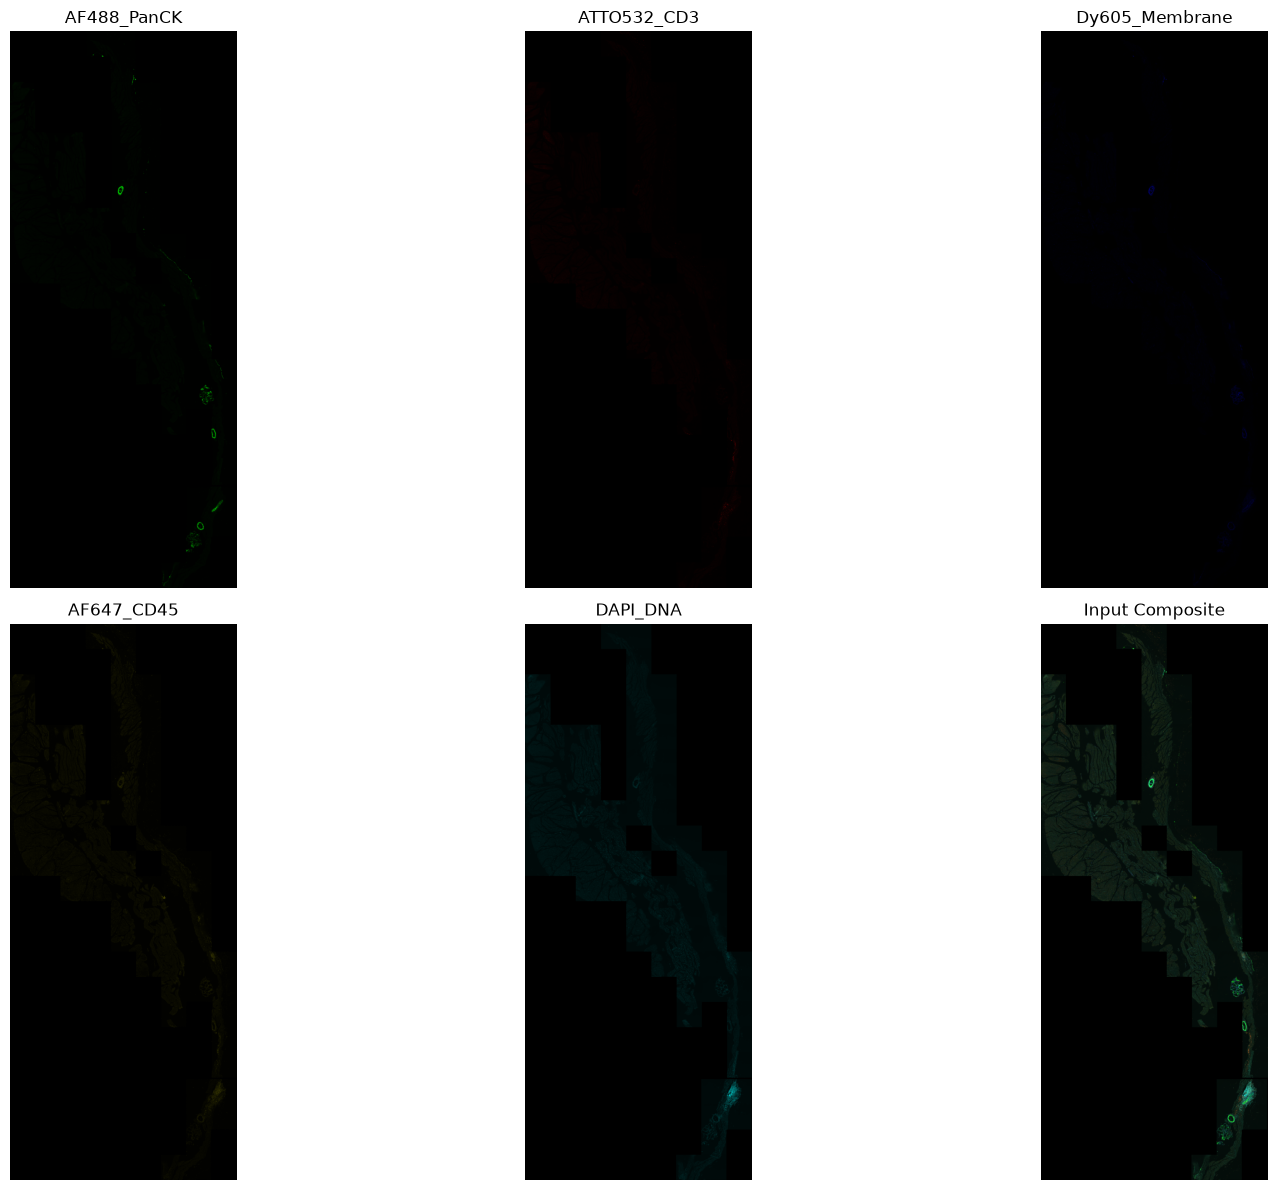

In [17]:
input_composite = np.zeros((z_img2.shape[1], z_img2.shape[2], 3), dtype=np.float32)
input_colored = []
for ch in range(NUM_CHANNELS):
    gray = channels_u8[ch].astype(np.float32) / 255.0
    color = np.array(CHANNEL_COLORS[ch], dtype=np.float32)
    input_colored.append((gray[:, :, None] * color[None, None, :]).astype(np.uint8))
    input_composite += gray[:, :, None] * color[None, None, :]
input_composite = np.clip(input_composite, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i in range(NUM_CHANNELS):
    row, col = divmod(i, 3)
    axes[row][col].imshow(input_colored[i])
    axes[row][col].set_title(CHANNEL_NAMES[i])
    axes[row][col].axis("off")
axes[1][2].imshow(input_composite)
axes[1][2].set_title("Input Composite")
axes[1][2].axis("off")
plt.tight_layout()
plt.show()

In [18]:
warp_transform(
    channels_u8, align_tf, d=(10, 10), scale=(1, 1), verbose=False, preflight=True
)

PreflightTransformationResult(img_shape=(-1, np.int32(3479), np.int32(1095)), offset=(-537, -16))

In [19]:
result = warp_transform(channels_u8, align_tf, d=(8, 8), scale=[1.0, 1.0], verbose=True)
print(f"Output shape: {result.img.shape}")
print(f"Output img_shape: {result.img_shape}")
print(f"Offset: {result.offset}")

[warp] input: 1197x2934, dx=8, dy=8, scale=[1.0, 1.0]
[warp] computing forward bbox (border scan)...
[warp] output: 1095x3479, offset=(-537, -16)
[warp] grid: 368x151 = 55568 points, 110100 triangles
[warp] forward-transforming grid points...
[warp] warping 110100 triangles...
  [warp] triangle 200/110100
  [warp] triangle 400/110100
  [warp] triangle 600/110100
  [warp] triangle 800/110100
  [warp] triangle 1000/110100
  [warp] triangle 1200/110100
  [warp] triangle 1400/110100
  [warp] triangle 1600/110100
  [warp] triangle 1800/110100
  [warp] triangle 2000/110100
  [warp] triangle 2200/110100
  [warp] triangle 2400/110100
  [warp] triangle 2600/110100
  [warp] triangle 2800/110100
  [warp] triangle 3000/110100
  [warp] triangle 3200/110100
  [warp] triangle 3400/110100
  [warp] triangle 3600/110100
  [warp] triangle 3800/110100
  [warp] triangle 4000/110100
  [warp] triangle 4200/110100
  [warp] triangle 4400/110100
  [warp] triangle 4600/110100
  [warp] triangle 4800/110100
  [war

In [20]:
warped = result.img
colored_warped = []
for ch in range(NUM_CHANNELS):
    gray = warped[ch].astype(np.float32) / 255.0
    color = np.array(CHANNEL_COLORS[ch], dtype=np.float32)
    colored = (gray[:, :, None] * color[None, None, :]).astype(np.uint8)
    colored_warped.append(colored)

# fig, axes = plt.subplots(1, NUM_CHANNELS, figsize=(6 * NUM_CHANNELS, 6))
# for i in range(NUM_CHANNELS):
#     axes[i].imshow(colored_warped[i])
#     axes[i].set_title(f"{CHANNEL_NAMES[i]} (warped)")
#     axes[i].axis("off")
# plt.tight_layout()
# plt.show()

In [21]:
H_dst, W_dst = warped.shape[1], warped.shape[2]
composite = np.zeros((H_dst, W_dst, 3), dtype=np.float32)
for ch in range(NUM_CHANNELS):
    gray = warped[ch].astype(np.float32) / 255.0
    color = np.array(CHANNEL_COLORS[ch], dtype=np.float32)
    composite += gray[:, :, None] * color[None, None, :]
composite = np.clip(composite, 0, 255).astype(np.uint8)

cv.imwrite("test_output.png", composite)

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# for i in range(NUM_CHANNELS):
#     row, col = divmod(i, 3)
#     axes[row][col].imshow(colored_warped[i])
#     axes[row][col].set_title(f"{CHANNEL_NAMES[i]} (warped)")
#     axes[row][col].axis("off")
# axes[1][2].imshow(composite)
# axes[1][2].set_title("Output Composite (all 5)")
# axes[1][2].axis("off")
# plt.tight_layout()
# plt.show()

True

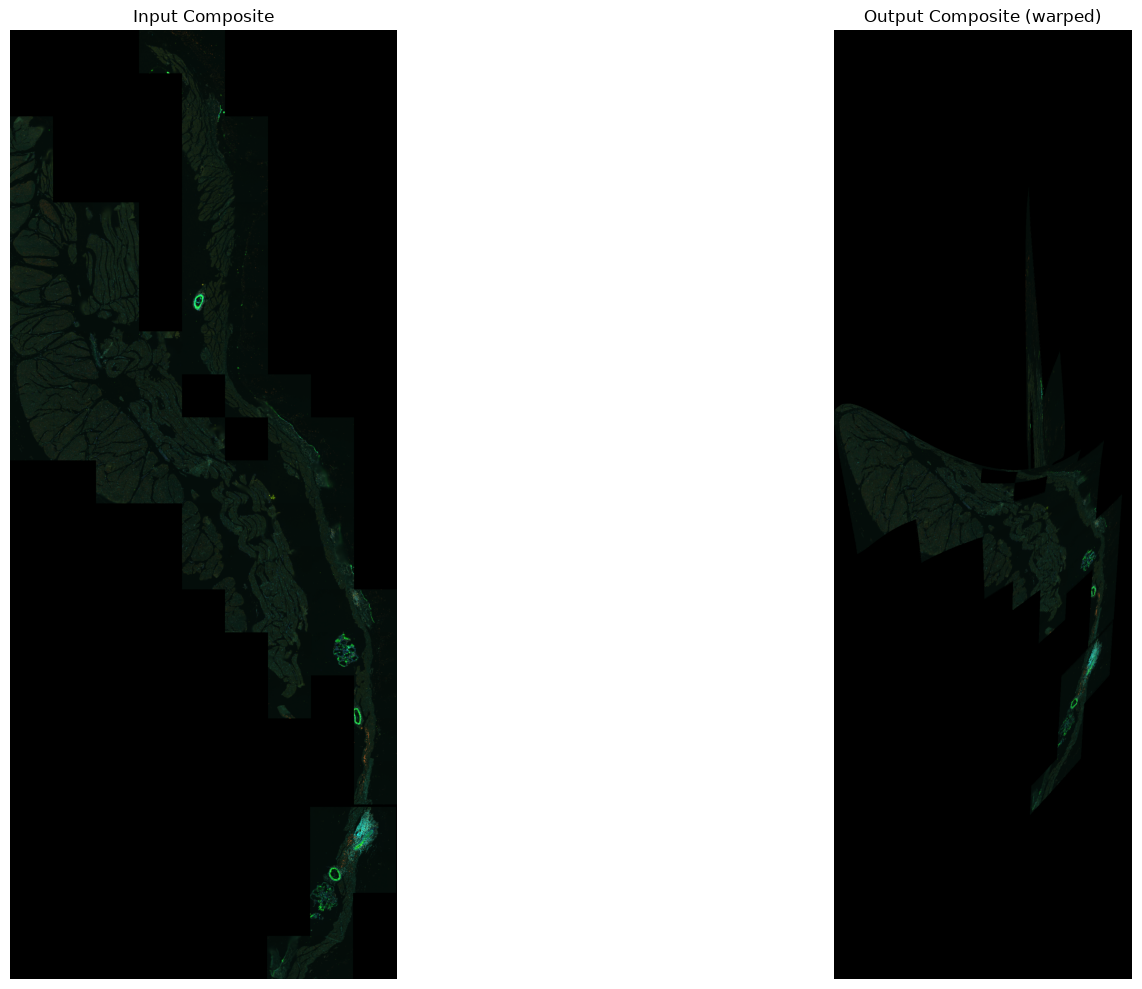

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(input_composite)
axes[0].set_title("Input Composite")
axes[0].axis("off")
axes[1].imshow(composite)
axes[1].set_title("Output Composite (warped)")
axes[1].axis("off")
plt.tight_layout()
plt.show()